In [ ]:
##polynomial trend

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Load your dataset
df = pd.read_csv("../milestone1/data/energy_data.csv")

# Create total power
df['total_power'] = df['fridge'] + df['ac']

df.head()

,timestamp,fridge,ac,lights,microwave,total_power
0,2023-01-01 00:00:00,0,0,48,948,0
1,2023-01-01 01:00:00,0,0,21,0,0
2,2023-01-01 02:00:00,156,0,65,0,156
3,2023-01-01 03:00:00,58,0,76,0,58
4,2023-01-01 04:00:00,160,0,44,0,160


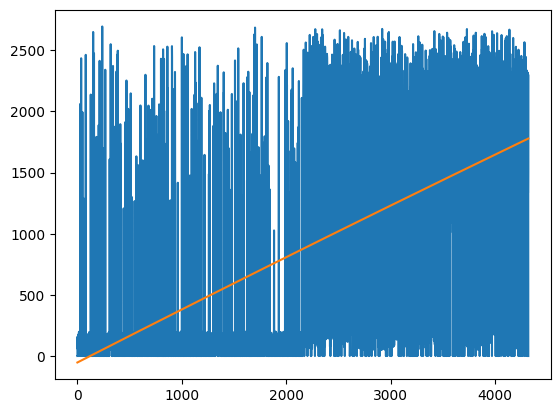

In [10]:
x = np.arange(len(df))
y = df['total_power']

coeff = np.polyfit(x, y, 2)
trend = np.poly1d(coeff)

plt.plot(x, y)
plt.plot(x, trend(x))
plt.show()

In [ ]:
##higher drgree polynomial

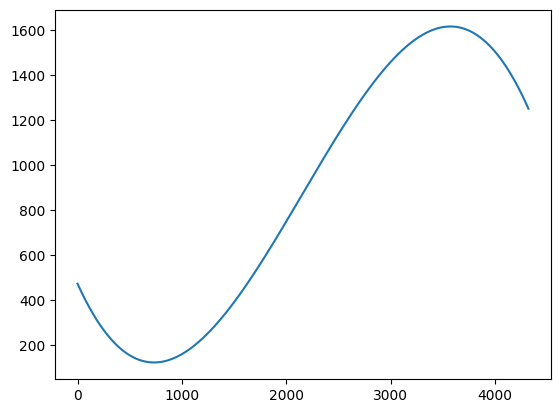

In [11]:
coeff = np.polyfit(x, y, 3)
trend = np.poly1d(coeff)

plt.plot(x, trend(x))
plt.show()

In [ ]:
##compare polynomial trends

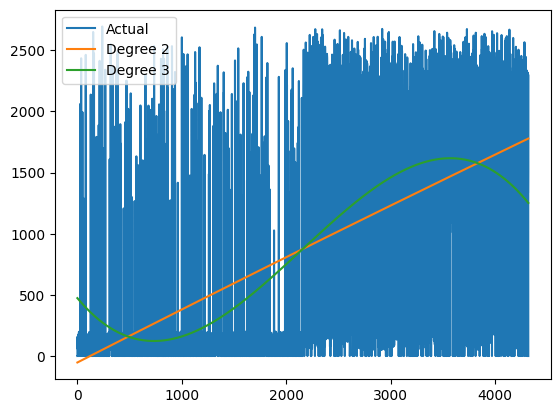

In [12]:
trend2 = np.poly1d(np.polyfit(x, y, 2))
trend3 = np.poly1d(np.polyfit(x, y, 3))

plt.plot(x, y, label='Actual')
plt.plot(x, trend2(x), label='Degree 2')
plt.plot(x, trend3(x), label='Degree 3')
plt.legend()
plt.show()

In [ ]:
##average power

In [13]:
df['total_power'].mean()

np.float64(871.600092571164)

In [15]:
df['timestamp'] = pd.to_datetime(df['timestamp'])

In [16]:
##daily avg
df['date'] = df['timestamp'].dt.date
df.groupby('date')['total_power'].mean()

date
2023-01-01      75.541667
2023-01-02     269.750000
2023-01-03     209.416667
2023-01-04     221.958333
2023-01-05      70.333333
                 ...     
2023-06-26    1313.416667
2023-06-27    1251.083333
2023-06-28    1615.750000
2023-06-29    1353.541667
2023-06-30       0.000000
Name: total_power, Length: 181, dtype: float64

<Axes: >

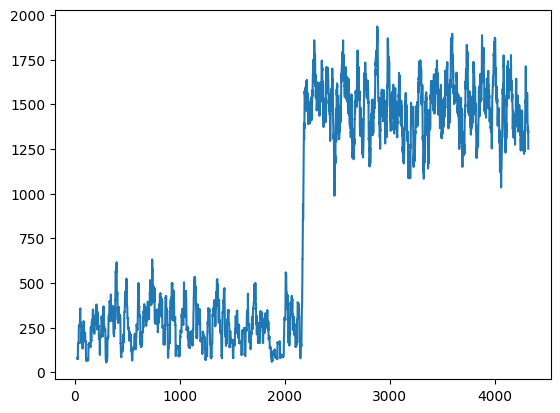

In [17]:
##rolling avg
df['rolling_avg'] = df['total_power'].rolling(24).mean()
df['rolling_avg'].plot()

In [ ]:
##volatility

In [18]:
df['total_power'].std()

np.float64(926.1904430495316)

<Axes: >

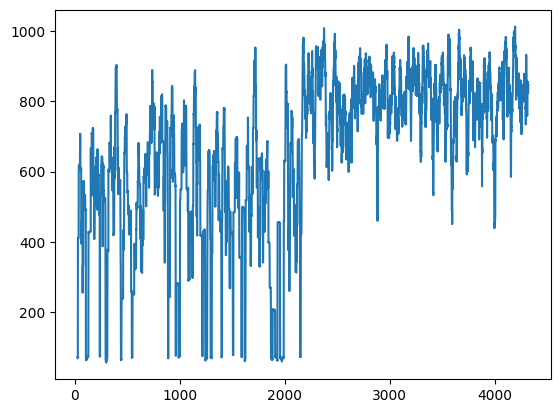

In [19]:
##rolling volatility
df['volatility'] = df['total_power'].rolling(24).std()
df['volatility'].plot()

<Axes: >

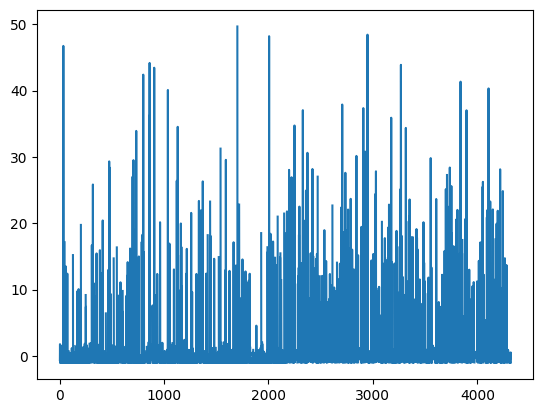

In [20]:
##percentage change
df['pct_change'] = df['total_power'].pct_change()
df['pct_change'].plot()


In [ ]:
##distribution

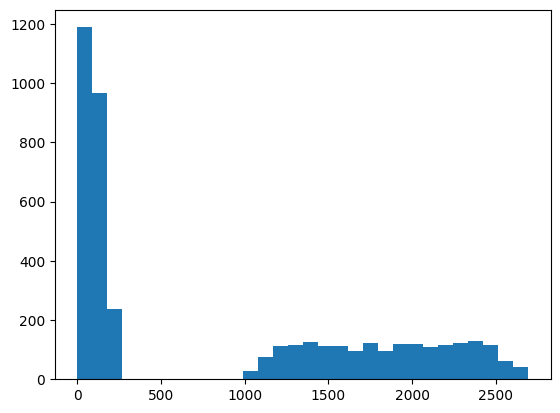

In [21]:
plt.hist(df['total_power'], bins=30)
plt.show()

<Axes: ylabel='Frequency'>

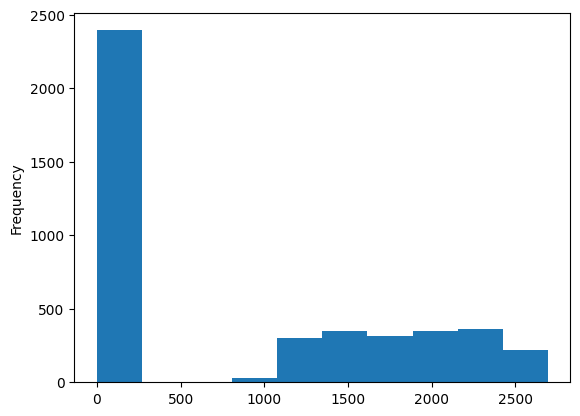

In [22]:
df['total_power'].plot(kind='hist')

In [23]:
df['total_power'].value_counts().head()

total_power
0      750
96      21
193     19
192     18
179     17
Name: count, dtype: int64

In [ ]:
##probability distribution

<Axes: ylabel='Density'>

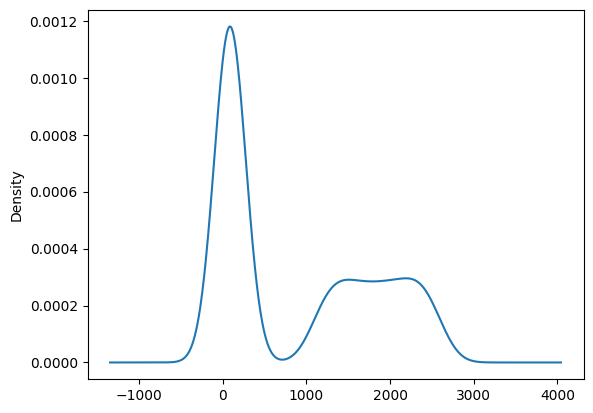

In [24]:
df['total_power'].plot(kind='density')

<Axes: xlabel='total_power', ylabel='Density'>

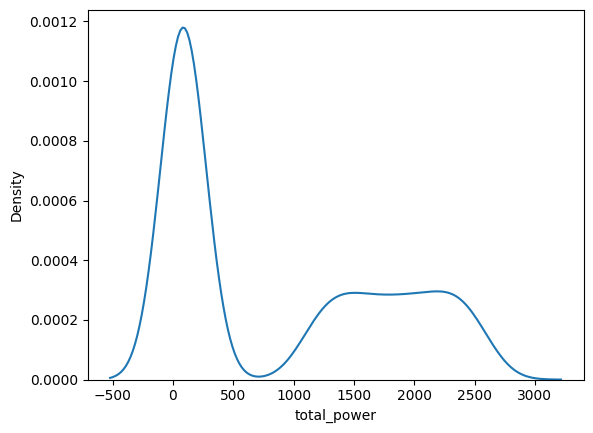

In [25]:
import seaborn as sns
sns.kdeplot(df['total_power'])

In [26]:
from scipy.stats import norm
mean = df['total_power'].mean()
std = df['total_power'].std()

In [ ]:
##CUSUM

In [27]:
df['cusum'] = (df['total_power'] - df['total_power'].mean()).cumsum()

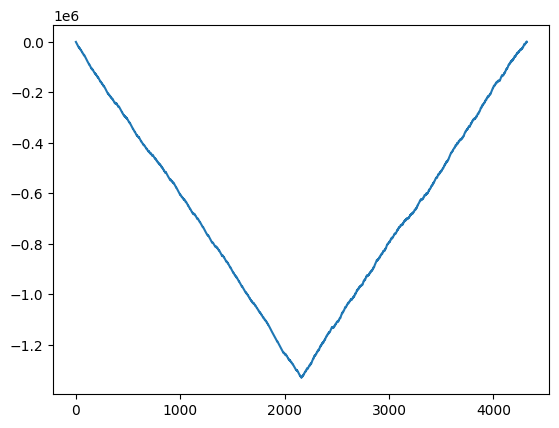

In [28]:
plt.plot(df['cusum'])
plt.show()

<Axes: >

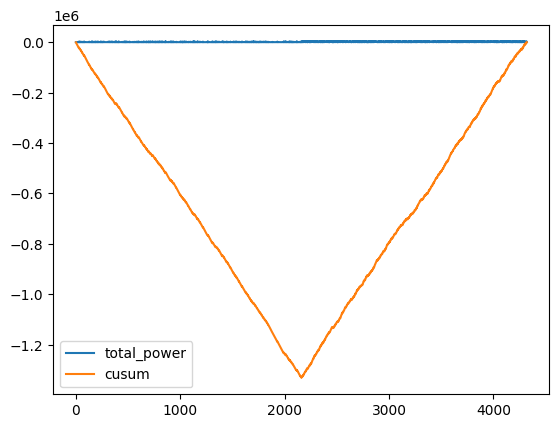

In [29]:
df[['total_power','cusum']].plot()

In [ ]:
##CORRELATION

In [30]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns



In [31]:
df['total_power'] = df['fridge'] + df['ac']
data = df[['fridge', 'ac', 'total_power']]




In [32]:
pearson_corr = data.corr(method='pearson')
print("Pearson Correlation:\n", pearson_corr)


Pearson Correlation:
                fridge        ac  total_power
fridge       1.000000  0.019055     0.092778
ac           0.019055  1.000000     0.997274
total_power  0.092778  0.997274     1.000000


In [ ]:
#Spearman Correlation

In [33]:
spearman_corr = data.corr(method='spearman')
print("\nSpearman Correlation:\n", spearman_corr)




Spearman Correlation:
                fridge        ac  total_power
fridge       1.000000  0.018506     0.350588
ac           0.018506  1.000000     0.912147
total_power  0.350588  0.912147     1.000000


In [ ]:
#Kendall Correlation

In [34]:
kendall_corr = data.corr(method='kendall')
print("\nKendall Correlation:\n", kendall_corr)



Kendall Correlation:
                fridge        ac  total_power
fridge       1.000000  0.013952     0.327622
ac           0.013952  1.000000     0.821734
total_power  0.327622  0.821734     1.000000


In [ ]:
##heatmap visualization

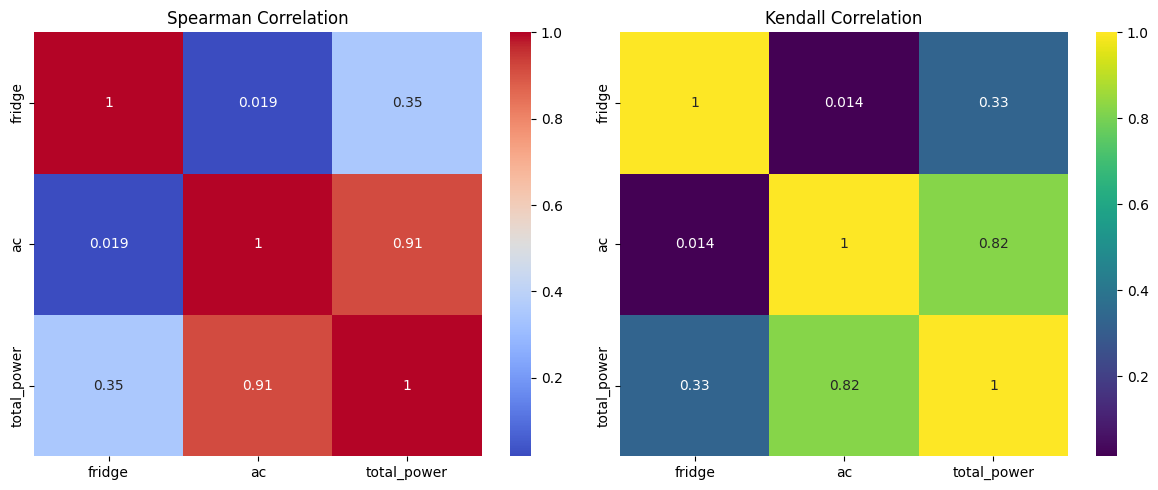

In [35]:
plt.figure(figsize=(12,5))

# Spearman Heatmap
plt.subplot(1,2,1)
sns.heatmap(spearman_corr, annot=True, cmap='coolwarm')
plt.title("Spearman Correlation")

# Kendall Heatmap
plt.subplot(1,2,2)
sns.heatmap(kendall_corr, annot=True, cmap='viridis')
plt.title("Kendall Correlation")

plt.tight_layout()
plt.show()



In [ ]:
##scatter plot

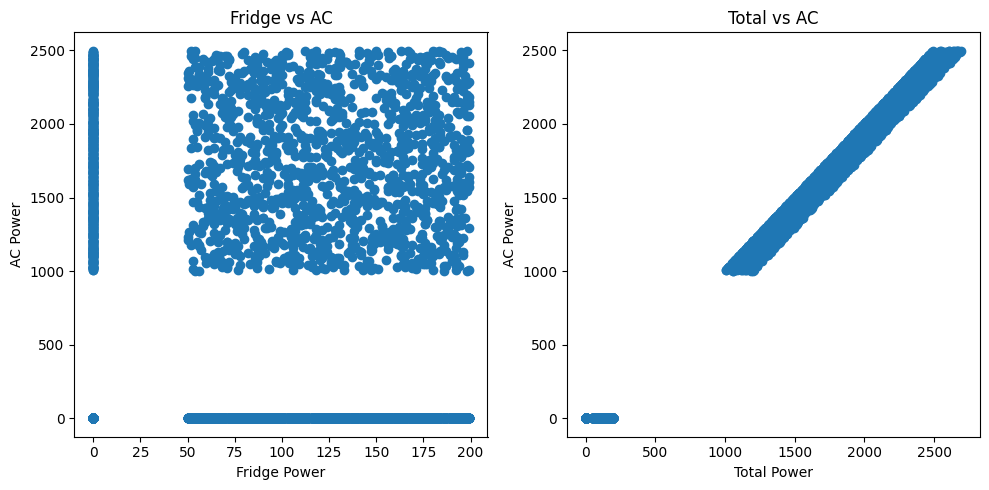

In [36]:
plt.figure(figsize=(10,5))

plt.subplot(1,2,1)
plt.scatter(df['fridge'], df['ac'])
plt.xlabel("Fridge Power")
plt.ylabel("AC Power")
plt.title("Fridge vs AC")

plt.subplot(1,2,2)
plt.scatter(df['total_power'], df['ac'])
plt.xlabel("Total Power")
plt.ylabel("AC Power")
plt.title("Total vs AC")

plt.tight_layout()
plt.show()


In [ ]:
##interpretation

In [37]:

print("\nINTERPRETATION:")
print("Spearman measures monotonic relationship (rank-based).")
print("Kendall measures strength of dependency between variables.")

if spearman_corr.loc['fridge','ac'] > 0:
    print("Fridge and AC are positively correlated (Spearman).")
else:
    print("Fridge and AC are negatively correlated (Spearman).")


INTERPRETATION:
Spearman measures monotonic relationship (rank-based).
Kendall measures strength of dependency between variables.
Fridge and AC are positively correlated (Spearman).


In [38]:
##QQ plot

((array([-3.59789629, -3.36026085, -3.22916881, ...,  3.22916881,
          3.36026085,  3.59789629], shape=(4321,)),
  array([   0,    0,    0, ..., 2675, 2686, 2695], shape=(4321,))),
 (np.float64(827.4391594319711),
  np.float64(871.600092571164),
  np.float64(0.892803194246366)))

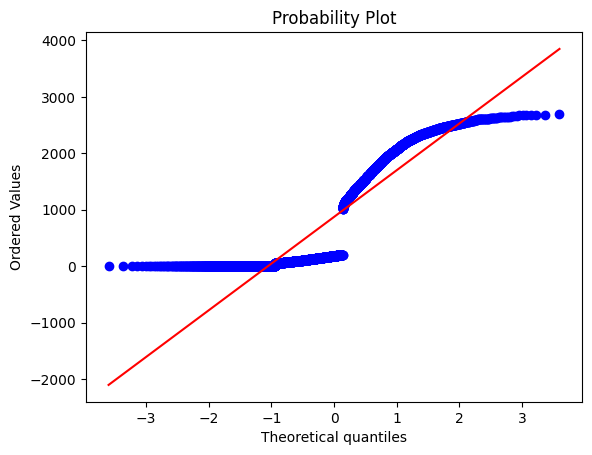

In [39]:
import scipy.stats as stats
stats.probplot(df['total_power'], plot=plt)

((array([-3.59789629, -3.36026085, -3.22916881, ...,  3.22916881,
          3.36026085,  3.59789629], shape=(4321,)),
  array([  0,   0,   0, ..., 199, 199, 199], shape=(4321,))),
 (np.float64(64.5162118361891),
  np.float64(87.70793797732007),
  np.float64(0.9432404381658182)))

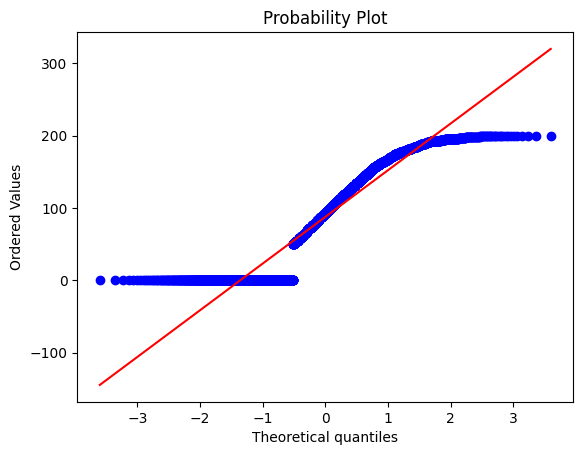

In [40]:
stats.probplot(df['fridge'], plot=plt)

((array([-3.59789629, -3.36026085, -3.22916881, ...,  3.22916881,
          3.36026085,  3.59789629], shape=(4321,)),
  array([   0,    0,    0, ..., 2497, 2497, 2497], shape=(4321,))),
 (np.float64(802.9658775112946),
  np.float64(783.892154593844),
  np.float64(0.8699917413169108)))

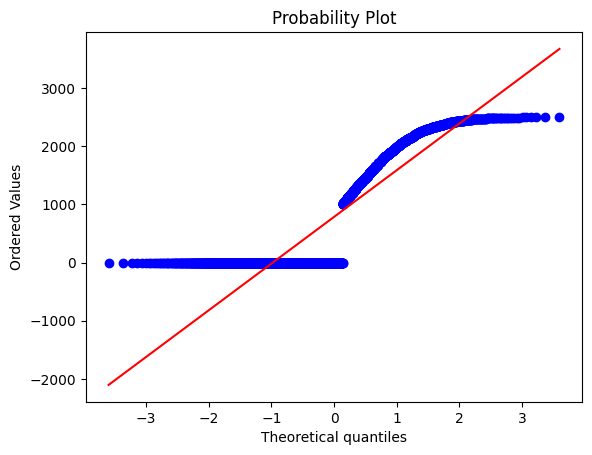

In [41]:
stats.probplot(df['ac'], plot=plt)

In [ ]:
##holt-winters

In [42]:
from statsmodels.tsa.holtwinters import ExponentialSmoothing
model = ExponentialSmoothing(df['total_power'])
fit = model.fit()

In [43]:
forecast = fit.forecast(50)

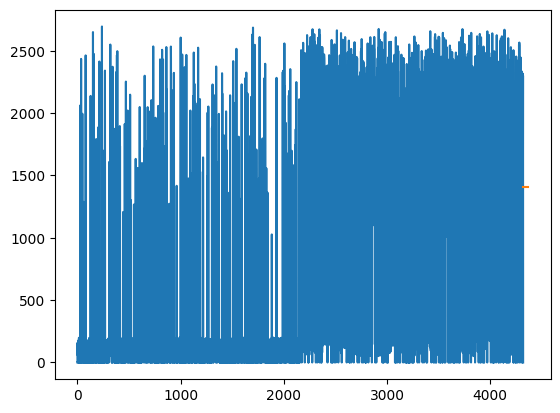

In [44]:
plt.plot(df['total_power'])
plt.plot(forecast)
plt.show()

In [ ]:
##GRANGER CAUSALITY

In [45]:
from statsmodels.tsa.stattools import grangercausalitytests
data = df[['total_power','fridge']]

In [46]:
grangercausalitytests(data, maxlag=2)


Granger Causality
number of lags (no zero) 1
ssr based F test:         F=6.5268  , p=0.0107  , df_denom=4317, df_num=1
ssr based chi2 test:   chi2=6.5314  , p=0.0106  , df=1
likelihood ratio test: chi2=6.5265  , p=0.0106  , df=1
parameter F test:         F=6.5268  , p=0.0107  , df_denom=4317, df_num=1

Granger Causality
number of lags (no zero) 2
ssr based F test:         F=2.7564  , p=0.0636  , df_denom=4314, df_num=2
ssr based chi2 test:   chi2=5.5192  , p=0.0633  , df=2
likelihood ratio test: chi2=5.5157  , p=0.0634  , df=2
parameter F test:         F=2.7564  , p=0.0636  , df_denom=4314, df_num=2


{np.int64(1): ({'ssr_ftest': (np.float64(6.5268484305843675),
    np.float64(0.01065982006320579),
    np.float64(4317.0),
    np.int64(1)),
   'ssr_chi2test': (np.float64(6.531384113996865),
    np.float64(0.010598745192779584),
    np.int64(1)),
   'lrtest': (np.float64(6.526451703131897),
    np.float64(0.010628176689525709),
    np.int64(1)),
   'params_ftest': (np.float64(6.526848430589627),
    np.float64(0.010659820063174319),
    np.float64(4317.0),
    1.0)},
   array([[0., 1., 0.]])]),
 np.int64(2): ({'ssr_ftest': (np.float64(2.756392771999635),
    np.float64(0.06363236224244587),
    np.float64(4314.0),
    np.int64(2)),
   'ssr_chi2test': (np.float64(5.519174957008078),
    np.float64(0.06331788296065327),
    np.int64(2)),
   'lrtest': (np.float64(5.515651529538445),
    np.float64(0.0634295292602585),
    np.int64(2)),
   'params_ftest': (np.float64(2.756392772000283),
    np.float64(0.06363236224240464),
    np.float64(4314.0),
    2.0)},
   array([[0., 0., 1., 0., 0.],

In [47]:
data = df[['total_power','ac']]
grangercausalitytests(data, maxlag=2)


Granger Causality
number of lags (no zero) 1
ssr based F test:         F=6.5268  , p=0.0107  , df_denom=4317, df_num=1
ssr based chi2 test:   chi2=6.5314  , p=0.0106  , df=1
likelihood ratio test: chi2=6.5265  , p=0.0106  , df=1
parameter F test:         F=6.5268  , p=0.0107  , df_denom=4317, df_num=1

Granger Causality
number of lags (no zero) 2
ssr based F test:         F=2.7564  , p=0.0636  , df_denom=4314, df_num=2
ssr based chi2 test:   chi2=5.5192  , p=0.0633  , df=2
likelihood ratio test: chi2=5.5157  , p=0.0634  , df=2
parameter F test:         F=2.7564  , p=0.0636  , df_denom=4314, df_num=2


{np.int64(1): ({'ssr_ftest': (np.float64(6.526848430585766),
    np.float64(0.01065982006319742),
    np.float64(4317.0),
    np.int64(1)),
   'ssr_chi2test': (np.float64(6.531384113998266),
    np.float64(0.010598745192771269),
    np.int64(1)),
   'lrtest': (np.float64(6.526451703131897),
    np.float64(0.010628176689525709),
    np.int64(1)),
   'params_ftest': (np.float64(6.526848430559751),
    np.float64(0.010659820063353087),
    np.float64(4317.0),
    1.0)},
   array([[0., 1., 0.]])]),
 np.int64(2): ({'ssr_ftest': (np.float64(2.7563927719984855),
    np.float64(0.06363236224251885),
    np.float64(4314.0),
    np.int64(2)),
   'ssr_chi2test': (np.float64(5.519174957005776),
    np.float64(0.06331788296072612),
    np.int64(2)),
   'lrtest': (np.float64(5.515651529538445),
    np.float64(0.0634295292602585),
    np.int64(2)),
   'params_ftest': (np.float64(2.7563927719958405),
    np.float64(0.06363236224268694),
    np.float64(4314.0),
    2.0)},
   array([[0., 0., 1., 0., 0.]

In [ ]:
print("test")